In [ ]:
## create data directory where all simulations will be stored
! mkdir -p ../data

In [1]:
%cd ../data

/nfs/scistore26/saricgrp/fhorvath/0__treadmilling/D__hydr/2__box/z__testcode/data


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import functions as fct
from tqdm.notebook import tqdm
import os
from jinja2 import Environment, FileSystemLoader

Septal bins set: 19 y-bins, -44.5 to 41.0 nm in steps of 4.5 nm (0.9 sim units)


# Setup

Write template input file

In [ ]:
%%file config_template.jinja
log                 log.txt
units               lj
dimension           2
atom_style          molecular
read_data           configuration.txt extra/bond/per/atom 5  extra/special/per/atom 20  extra/angle/per/atom 3

variable            tscale equal {{ tscale }} ## time is in step*${tstep}/tscale seconds
variable            ron equal {{ ron }}/${tscale}                                # growth rate [monomers/s]
variable            rdis equal {{ rdis }}/${tscale}                               # dissociation rate [monomers/s]
variable            rnuc equal {{ "%0.5f" | format(rnuc | float) }}/${tscale}                    # nucleation rate [filaments/s]
variable            tauhyd equal {{ tauhyd }}*${tscale}                          # hydrolysis time [seconds]
variable            Kbond equal 1000.0                               # bond constant [kT/sigma2]
variable            tstep equal {{ tstep }}                                # simulation timestep size [seconds]
variable            realtime equal step*${tstep}/${tscale}            # simulation time in real units [seconds]
variable            run_time equal {{ runtime }}*${tscale}                            # simulation run time [seconds]
variable            treact equal 0.010000*${tscale}                            # reaction attempt time [seconds]
variable            tnuc equal {{ tnuc }}*${tscale}                           # nucleation reaction attempt time [seconds]

variable            modtime equal {{ modtime }}                         # modulation time [seconds]
variable            condmod equal "v_realtime > v_modtime"
variable            ratesratio equal {{ ratesratio }}

variable            frame_rate equal {{ frame_rate }}*${tscale}                          # coarse dumping interval [seconds]
variable            seed equal {{ seed }}                                  # random number generator seed
variable            maxatoms equal {{ saturate }}+4872                              # maximum number of atoms allowed in the system
variable            fCurv equal {{ fCurv }}                                 # magnitude of the curvature force [kT/sigma]
{% if arrt %}
variable            condarr equal "v_realtime < {{ arrt }}"             # arrest after some initial time
{% else %}
variable            condarr equal 1 # don't arrest
{% endif %}
variable            poff equal "1.0*v_condarr"                    # shrinking reaction initiation probability (0 or 1)
variable            condatoms equal "atoms >= v_maxatoms+2"
variable            pon equal 1 #(1-v_condatoms)                     # growing reaction initiation probability (0 or 1)

## synthase reactions
variable            pact equal {{ pact }} ## 5 to 6
{% if switchtime %}
## switch on synth-filament interactions after given time
variable            condattract equal "v_realtime >= {{ switchtime }}"
variable            pdeact equal "1.0*v_condattract"  ## 6 to 5
{% else %}
variable            pdeact equal {{ pdeact }}   ## 6 to 5
{% endif %}
variable            psynthbond equal {{ "%0.5f" | format(psynthbond | float) }}

## box modulation
variable  kswitch equal {{ kswitch }}
variable rswitch1 equal {{ xbox }}
variable rswitch2 equal -{{ xbox }}
variable s1 atom 1/(1 + exp(v_kswitch*(y - v_rswitch1)))
variable s2 atom 1/(1 + exp(v_kswitch*(y - v_rswitch2)))
variable bumpy atom v_s1 * (1 - v_s2)
variable sx1 atom 1/(1 + exp(v_kswitch*(x - v_rswitch1)))
variable sx2 atom 1/(1 + exp(v_kswitch*(x - v_rswitch2)))
variable bumpx atom v_sx1 * (1 - v_sx2)
variable kon atom v_ron*${treact}*v_ratesratio*(1-v_condmod) + v_ron*${treact}*v_bumpy*v_bumpx*v_condmod

variable            knuc atom v_ratesratio                        # nucleation probability
variable            pnuc0 equal v_pon*(1-v_condmod)
variable            pnuc1 equal v_pon*v_condmod
variable            kdis equal ${rdis}*${treact}                          # dissociation probability

variable            kdis equal ${rdis}*${treact}                          # dissociation probability

variable            thyd equal ${tauhyd}/${tstep}                 # hydrolysis time [simulation steps]
variable            rstep equal ${treact}/${tstep}                      # reaction interval [simulation steps]
variable            nucstep equal ${tnuc}/${tstep}                      # nucleation reaction interval [simulation steps]
variable            run_steps equal ${run_time}/${tstep}          # simulation run time [simulation steps]
variable            dump_time equal ${frame_rate}/${tstep}        # dumping interval [simulation steps]


variable            stab_steps equal 1
variable            synth_stab_steps equal 10 ## for synth binding on reaction

group               ghosts type 4

special_bonds       lj 1.0 1.0 1.0
bond_style          hybrid harmonic #morse 
bond_coeff          1 harmonic ${Kbond} 1.0


variable synthrmin equal {{ "%0.5f" | format(synthrmin | float) }}
variable synthrmax equal {{ "%0.5f" | format(synthrmax | float) }}

angle_style         harmonic
angle_coeff         1 {{ Kbend }} 180.0
angle_coeff         2 {{ Kobst }} 180.0

pair_style          hybrid/overlay zero 1.50 cosine/squared 1.50 soft 1.0
pair_coeff          * * cosine/squared 0.00 1.00 1.10
pair_coeff          * * zero 2
pair_coeff          5 7 zero 2
pair_coeff          1 5 zero 2
pair_coeff          3 5 zero 2
pair_coeff          1 6 zero 2
pair_coeff          1 {{ attracted_synth_type }} cosine/squared {{ eps }} 0.5 {{ synthrange }} wca
pair_coeff          2 {{ attracted_synth_type }} cosine/squared {{ eps }} 0.5 {{ synthrange }} wca
pair_coeff          3 {{ attracted_synth_type }} cosine/squared {{ eps }} 0.5 {{ synthrange }} wca
pair_coeff          5 5 soft 5 1
pair_coeff          6 6 soft 5 1
pair_coeff          5 6 soft 5 1

pair_coeff          1 1 cosine/squared {{ epscore }} 1.00 {{ crossrange }} wca
pair_coeff          1 2 cosine/squared 1.00 1.00 1.00 wca
pair_coeff          1 3 cosine/squared 1.00 1.00 1.00 wca
pair_coeff          2 2 cosine/squared 1.00 1.00 1.00 wca
pair_coeff          2 3 cosine/squared 1.00 1.00 1.00 wca
pair_coeff          3 3 cosine/squared 1.00 1.00 1.00 wca

#neigh_modify        exclude molecule/intra all

# Nucleation Reactions_rdis molecular templates
molecule            mPreNucleation {{ reactions }}pre_Nucleation.txt
molecule            mPostNucleation {{ reactions }}post_Nucleation.txt

# Growth Reactions_rdis molecular templates
molecule            mPreDimerOn {{ reactions }}pre_DimerOn.txt
molecule            mPostDimerOn {{ reactions }}post_DimerOn.txt
molecule            mPreTrimerOn {{ reactions }}pre_TrimerOn.txt
molecule            mPostTrimerOn {{ reactions }}post_TrimerOn.txt
molecule            mPreOligomerOn {{ reactions }}pre_OligomerOn.txt
molecule            mPostOligomerOn {{ reactions }}post_OligomerOn.txt

# Shrink Reactions_rdis molecular templates
molecule            mPreDimerOff {{ reactions }}pre_DimerOff.txt
molecule            mPostDimerOff {{ reactions }}post_DimerOff.txt
molecule            mPreTrimerOff {{ reactions }}pre_TrimerOff.txt
molecule            mPostTrimerOff {{ reactions }}post_TrimerOff.txt
molecule            mPreQuartomerOff {{ reactions }}pre_QuartomerOff.txt
molecule            mPostQuartomerOff {{ reactions }}post_QuartomerOff.txt
molecule            mPreOligomerOff {{ reactions }}pre_OligomerOff.txt
molecule            mPostOligomerOff {{ reactions }}post_OligomerOff.txt

# div templates
molecule mPreDiviAct {{ reactions }}pre_div_act.txt
molecule mPostDiviAct {{ reactions }}post_div_act.txt
molecule mPreDEact {{ reactions }}pre_DEact.txt
molecule mPostDEact {{ reactions }}post_DEact.txt

variable            vCreationSteps atom i_creation_steps
variable            vHydrolysisRn atom d_hydrolysis_rn
fix freact all bond/react  stabilization yes AllAtoms 0.1  reset_mol_ids molmap lifetime hydrolysis ${seed} &
                react Nucleation all ${nucstep} 0.900000 1.100000 mPreNucleation mPostNucleation {{ reactions }}map_Nucleation.txt prob v_pon ${seed} stabilize_steps ${stab_steps} modify_create overlap {{ roverlap }} modify_create nuc yes         &
                react DimerOn all ${rstep} 0.900000 1.100000 mPreDimerOn mPostDimerOn {{ reactions }}map_DimerOn.txt prob v_pon ${seed} stabilize_steps ${stab_steps} modify_create fit 1 modify_create overlap {{ roverlap }}         &
                react TrimerOn all ${rstep} 0.900000 1.100000 mPreTrimerOn mPostTrimerOn {{ reactions }}map_TrimerOn.txt prob v_pon ${seed} stabilize_steps ${stab_steps} modify_create fit 1 modify_create overlap {{ roverlap }}         &
                react OligomerOn all ${rstep} 0.900000 1.100000 mPreOligomerOn mPostOligomerOn {{ reactions }}map_OligomerOn.txt prob v_pon ${seed} stabilize_steps ${stab_steps} modify_create fit 1 modify_create overlap {{ roverlap }}         &
                react OligomerOff all ${rstep} 0.900000 1.100000 mPreOligomerOff mPostOligomerOff {{ reactions }}map_OligomerOff.txt prob v_poff ${seed} stabilize_steps ${stab_steps}         &
                react QuartomerOff all ${rstep} 0.900000 1.100000 mPreQuartomerOff mPostQuartomerOff {{ reactions }}map_QuartomerOff.txt prob v_poff ${seed} stabilize_steps ${stab_steps}         &
                react TrimerOff all ${rstep} 0.900000 1.100000 mPreTrimerOff mPostTrimerOff {{ reactions }}map_TrimerOff.txt prob v_poff ${seed} stabilize_steps ${stab_steps}         &
                react DimerOff all ${rstep} 0.900000 1.100000 mPreDimerOff mPostDimerOff {{ reactions }}map_DimerOff.txt prob v_poff ${seed} stabilize_steps ${stab_steps} &
				react diviact  &
					all  ${rstep}  &
					0.100000 10  &
					mPreDiviAct mPostDiviAct  {{ reactions }}map_DivAct.txt &
					prob v_pact ${seed} &
				react divideact &
					all ${rstep}   &
					0.000000 9999 &
					mPreDEact mPostDEact {{ reactions }}map_DEact.txt &
					prob v_pdeact ${seed} 

variable            vMaskHeadType atom "type==3"
group               HeadMons dynamic all var vMaskHeadType every 1
variable            vMaskTailType atom "type==2"
group               TailMons dynamic all var vMaskTailType every 1
variable            vMaskHTType atom "type==2 || type==3"
group               HTMons dynamic all var vMaskHTType every 1
variable            vMaskAlive atom "type==1 || type==2 || type==3"
group               alive dynamic all var vMaskAlive every 1
variable vStep atom "step"
fix      fStep all store/state 1 v_vStep


fix                 fLang all langevin 1.0 1.0 1.0 ${seed}

## INTEGRATE ONLY NONGHOST PARTICLES
fix fNVE AllAtoms_REACT nve
variable vMaskGrid atom "type==7"
group grid dynamic all var vMaskGrid every 100
variable vMaskReactNongrid atom "(1-gmask(grid)) * gmask(AllAtoms_REACT)"
group integr dynamic all var vMaskReactNongrid every 1
fix fNVE integr nve

#fix fNVE AllAtoms_REACT nve

## freeze grid particles
group grid type 7
fix freeze grid setforce 0 0 0
velocity grid set 0 0 0



## DONT OUTPUT GRID PARTICLES
variable vnongrid atom "(1-gmask(grid))"
group nongrid dynamic all var vnongrid every ${dump_time}
dump 1 nongrid custom ${dump_time} output.xyz v_vStep id mol type x y 
dump_modify 1 format line "%6.f %d %d %d %.1f %.1f" #  %.1f %.1f 

{% if calcIE %}
## CALCULATE INTERACTION ENERGIES
variable            ParticleMask atom "type==1 || type==2 || type==3 "
group               particles dynamic all var ParticleMask	 every 10
compute cPairs particles property/local patom1 patom2 ptype1 ptype2
compute pairlocal particles pair/local eng 
#dist eng force
dump 4 particles local ${dump_time} pairs.out c_cPairs[*] c_pairlocal 
{% endif %}


thermo              ${dump_time}
compute_modify      thermo_temp dynamic/dof yes
thermo_style        custom step v_realtime temp pe ke etotal epair ebond eangle press vol density atoms


## bonds output
#compute             cBonds all property/local batom1 batom2 btype
#compute             cBondDxys all bond/local engpot force dist
#dump 2 all local ${dump_time} bonds.dump c_cBonds[*] c_cBondDxys[*]
#dump_modify 2 format line "%.0f %.0f %.0f %.3f %.3f %.3f"

fix                 twodim all enforce2d

variable            restartsteps equal v_run_steps/20
restart             ${restartsteps} restart

timestep            ${tstep}
run                 ${run_steps}

Overwriting config_template.jinja


Define base values for all variables in the template

In [ ]:
# Define the directory where the template is saved
template_dir = "."  # Change if your template is in another folder
template_file = "config_template.jinja"  # Save the Jinja template with this name

# Load the template
env = Environment(loader=FileSystemLoader(template_dir))
template = env.get_template(template_file)

# Define values extracted from your config file
base_values = {
    "log_file": "log.txt",
    "units": "lj",
    "dimension": 2,
    "atom_style": "molecular",
    "read_data": "configuration.txt",
    "ron": 8.0,
    "rdis": 10.0,
    "tauhyd": 1.0,
    "rnuc": 10.0,
    "Kbond": 1000.0,
    "Kbend": 10000,
    "Kobst": 100.0,
    "tstep": 0.001,
    "runtime": 50000,
    "treact": 0.1,
    "modtime": 0.0,
    "ratesratio": 1.0,
    "frame_rate": 10,
    "fCurv": 0.0,
    "fSwim": 0.0,
    "pdeact": 1,
    "pact": 0,
    "stab_steps": 1,
    "epscore": 10,
    "eps": 10,
    "profW": 15,
    "arrt": False,
    "calcIE": False,
    "attracted_synth_type": 5,
    "switchtime": 600,  # time after which cargo-filament interactions are switched on
    #"restartsteps": 100000,
    "D": 10,
    "alpha" : 3.5,
    "r0" : 0.5,
    "synthrmin" : 0.5,
    "synthrmax" : 2.0,
    "seed" : 1234,
    "psynthbond": 1,
    "nbonds": 1,
    #"dtheta": 1,
    "tscale": 1,
    "m": 1,
    "reactions": "/nfs/scistore26/saricgrp/fhorvath/0__treadmilling/D__hydr/Reactions_explicit/molid/",
    "saturate": 0,
    "synthrange": 0.8,
    "Lx": 120,
    "n_synthases": 800,
    "kswitch": 0.1,
    "xbox": 40,
    "roverlap": 1,
    "mZ": 1,
    "tnuc": 0.01,
    "tstep": 0.001,
}

In [6]:
## use very short simulation times for testing
base_values["runtime"] = 50

In [7]:
# Render the template with values
config_output = template.render(base_values)

Define parameters that will be changed in the simulations:

In [8]:
# Define all possible parameter ranges
parameter_values = {
    "kswitch": [0.1, 0.2, 0.5],
    "tscale": [1, 2, 5, 10],
}

Create simulation folders and config.sh files

In [9]:
combinations, param_keys = fct.sys_setup.write_templates(parameter_values, base_values, template,
overwrite=True);

12


100%|██████████| 12/12 [00:00<00:00, 251.90it/s]


Create initial config configuration.txt files

In [10]:
fct.sys_setup.run_sweep(param_keys, combinations, base_values,)

 17%|█▋        | 2/12 [00:00<00:01,  8.62it/s]

grid entries: 1068
grid entries: 1068


 42%|████▏     | 5/12 [00:00<00:00,  9.75it/s]

grid entries: 1068
grid entries: 1068
grid entries: 1068


 67%|██████▋   | 8/12 [00:00<00:00,  9.87it/s]

grid entries: 1068
grid entries: 1068
grid entries: 1068


 92%|█████████▏| 11/12 [00:01<00:00,  9.96it/s]

grid entries: 1068
grid entries: 1068
grid entries: 1068


100%|██████████| 12/12 [00:01<00:00,  9.67it/s]

grid entries: 1068


# submit

Write all simulation directories to a file

In [11]:
! find "$(pwd)" -type d -name "runfiles" > rdir
! echo "number of runs: "
! wc -l rdir

number of runs: 
12 rdir


Submit runs

In [12]:
jobname = "test_simulations"

In [13]:
fct.utils.submit_runs("rdir", ## file with simulation directories
    jobname,
    cores=15, 
    mem="10G",
    # which lammps installation to use
    lmp_path='/nfs/scistore26/saricgrp/fhorvath/0__treadmilling/D__hydr/lammps_molid/lammps/build/lmp',
    # analysis script to run after the simulation is finished (optional)
    analysis_script="/nfs/scistore26/saricgrp/fhorvath/0__treadmilling/utils/read_xyz.ipynb",
    additional_analysis = ["/nfs/scistore26/saricgrp/fhorvath/0__treadmilling/utils/calc_finalframe.ipynb"]
)

Submitted batch job 62112163


In [34]:
## cancel jobs if necessary
## ! scancel 62111864

In [35]:
! squeue|grep {jobname[:8]}

# Results

In [36]:
%cd ../data

/nfs/scistore26/saricgrp/fhorvath/0__treadmilling/D__hydr/2__box/z__testcode/data


Create a dictionary D that will hold all data we collect across different simulations 
together with a dictionary prm that stores which parameters we iterate over

In [37]:
D, p, prm = fct.utils.load_runs()

Loaded dict with 12 keys


In [38]:
prm

{'kswitch': [0.1, 0.2, 0.5], 'tscale': [1, 2, 5, 10]}

# Plot final configurations

In [39]:
fct.load_data.load_pickles_into_D(D, ["finalframe.pkl",])

Loading serialized files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading serialized files: 100%|██████████| 12/12 [00:00<00:00, 757.45it/s]


12

In [40]:
prm

{'kswitch': [0.1, 0.2, 0.5], 'tscale': [1, 2, 5, 10]}

In [ ]:
xylim = 450
fct.plot.plot_data_(prm, D,
        grid_params=['kswitch', 'tscale'],
        overlay_params=[],
        #fixed_params={"epscore": 10},
        plot_function=lambda key, ax, overlay:
            fct.box.synth_scatter(ax, key, D),
        check_key="finalframe",
        # axis_edits={"set_aspect": "equal",
        #             "set_xlim": (-xylim,xylim),
        #             "set_ylim": (-xylim,xylim),
        #             },
    )

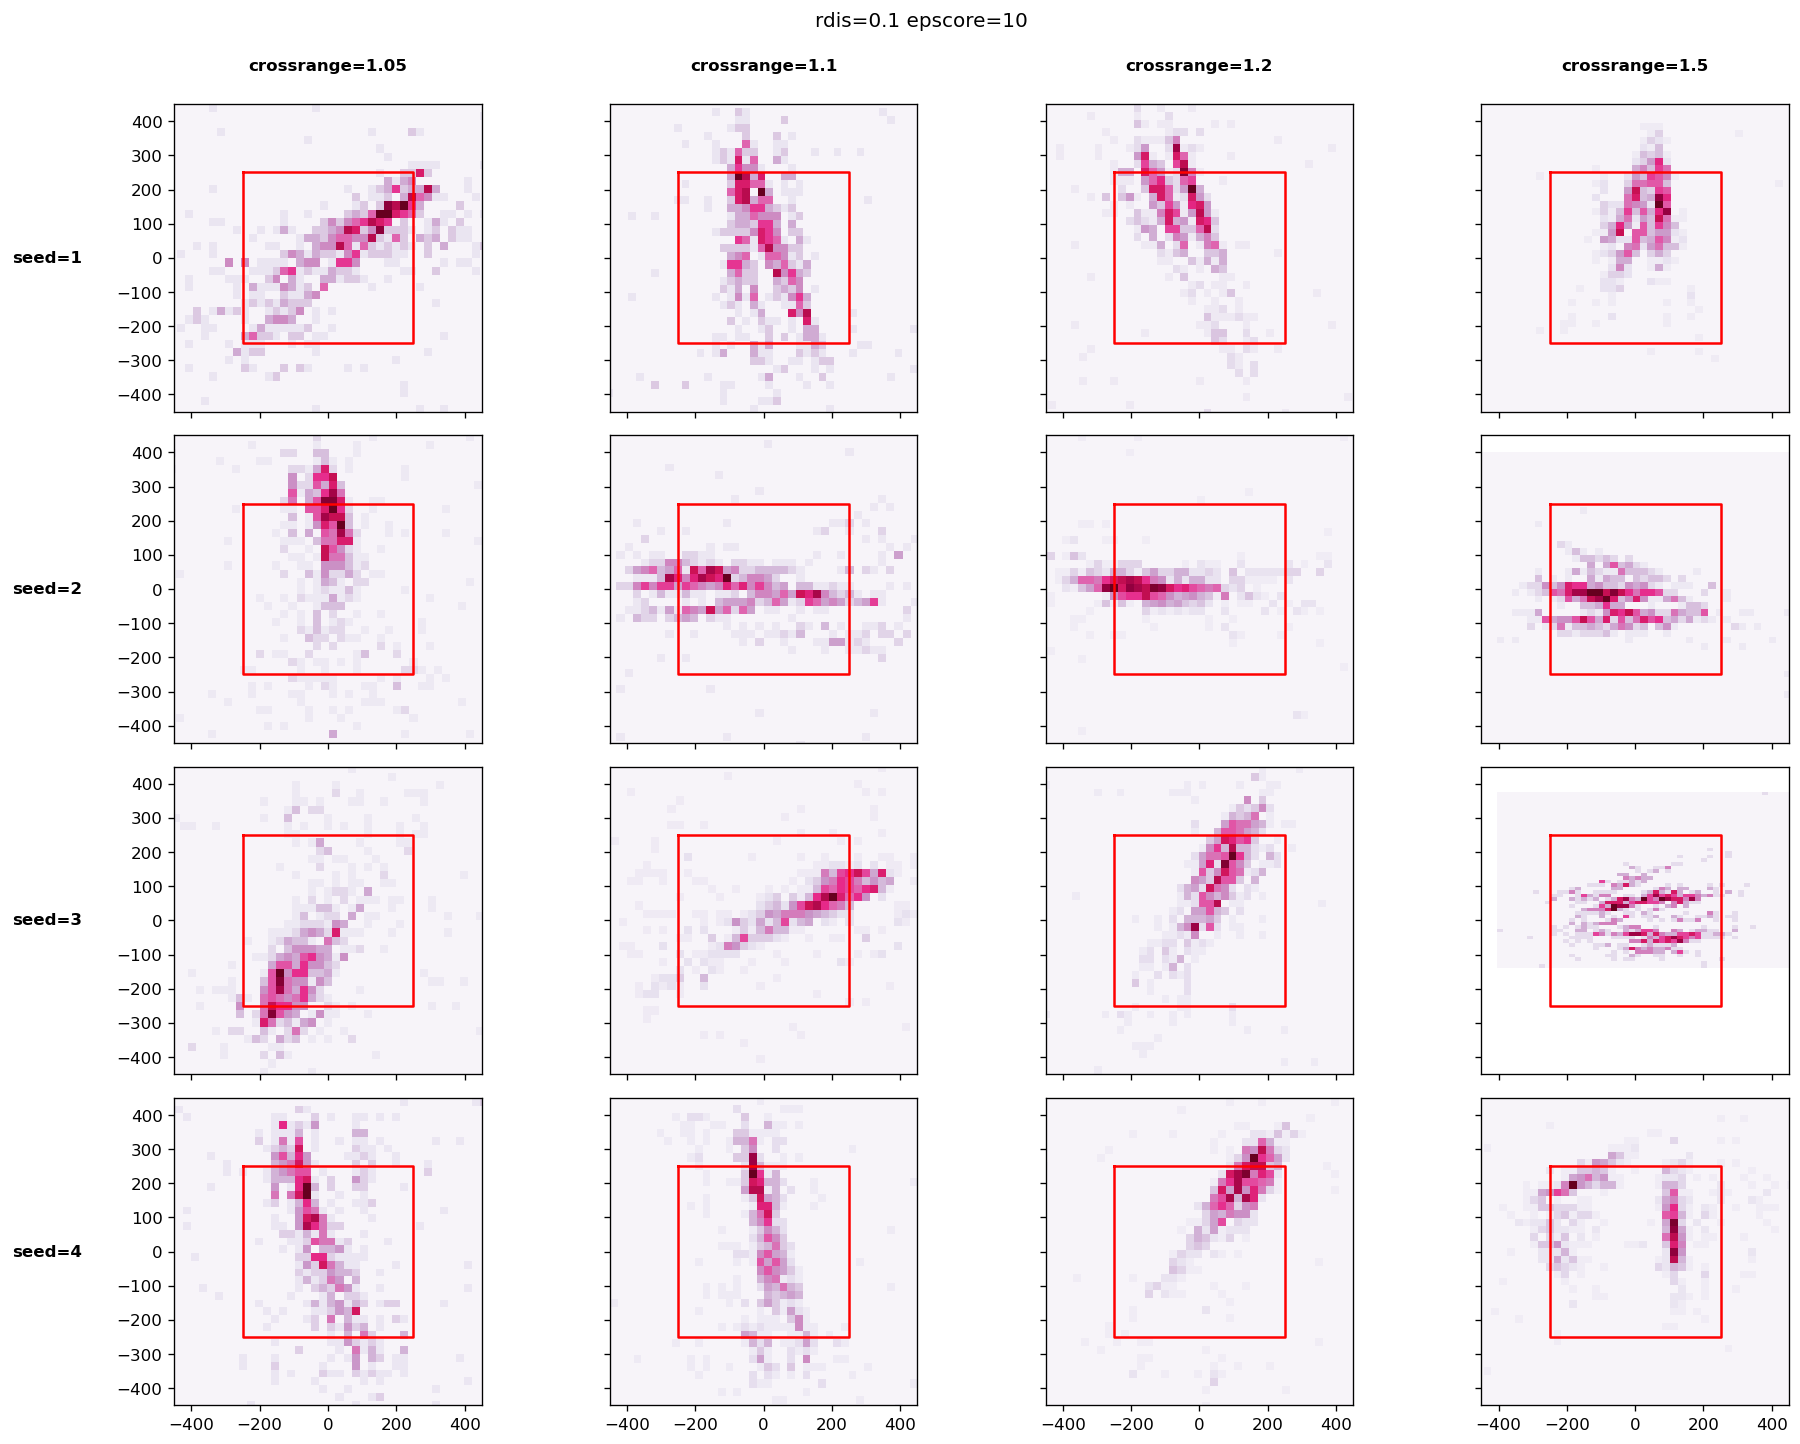

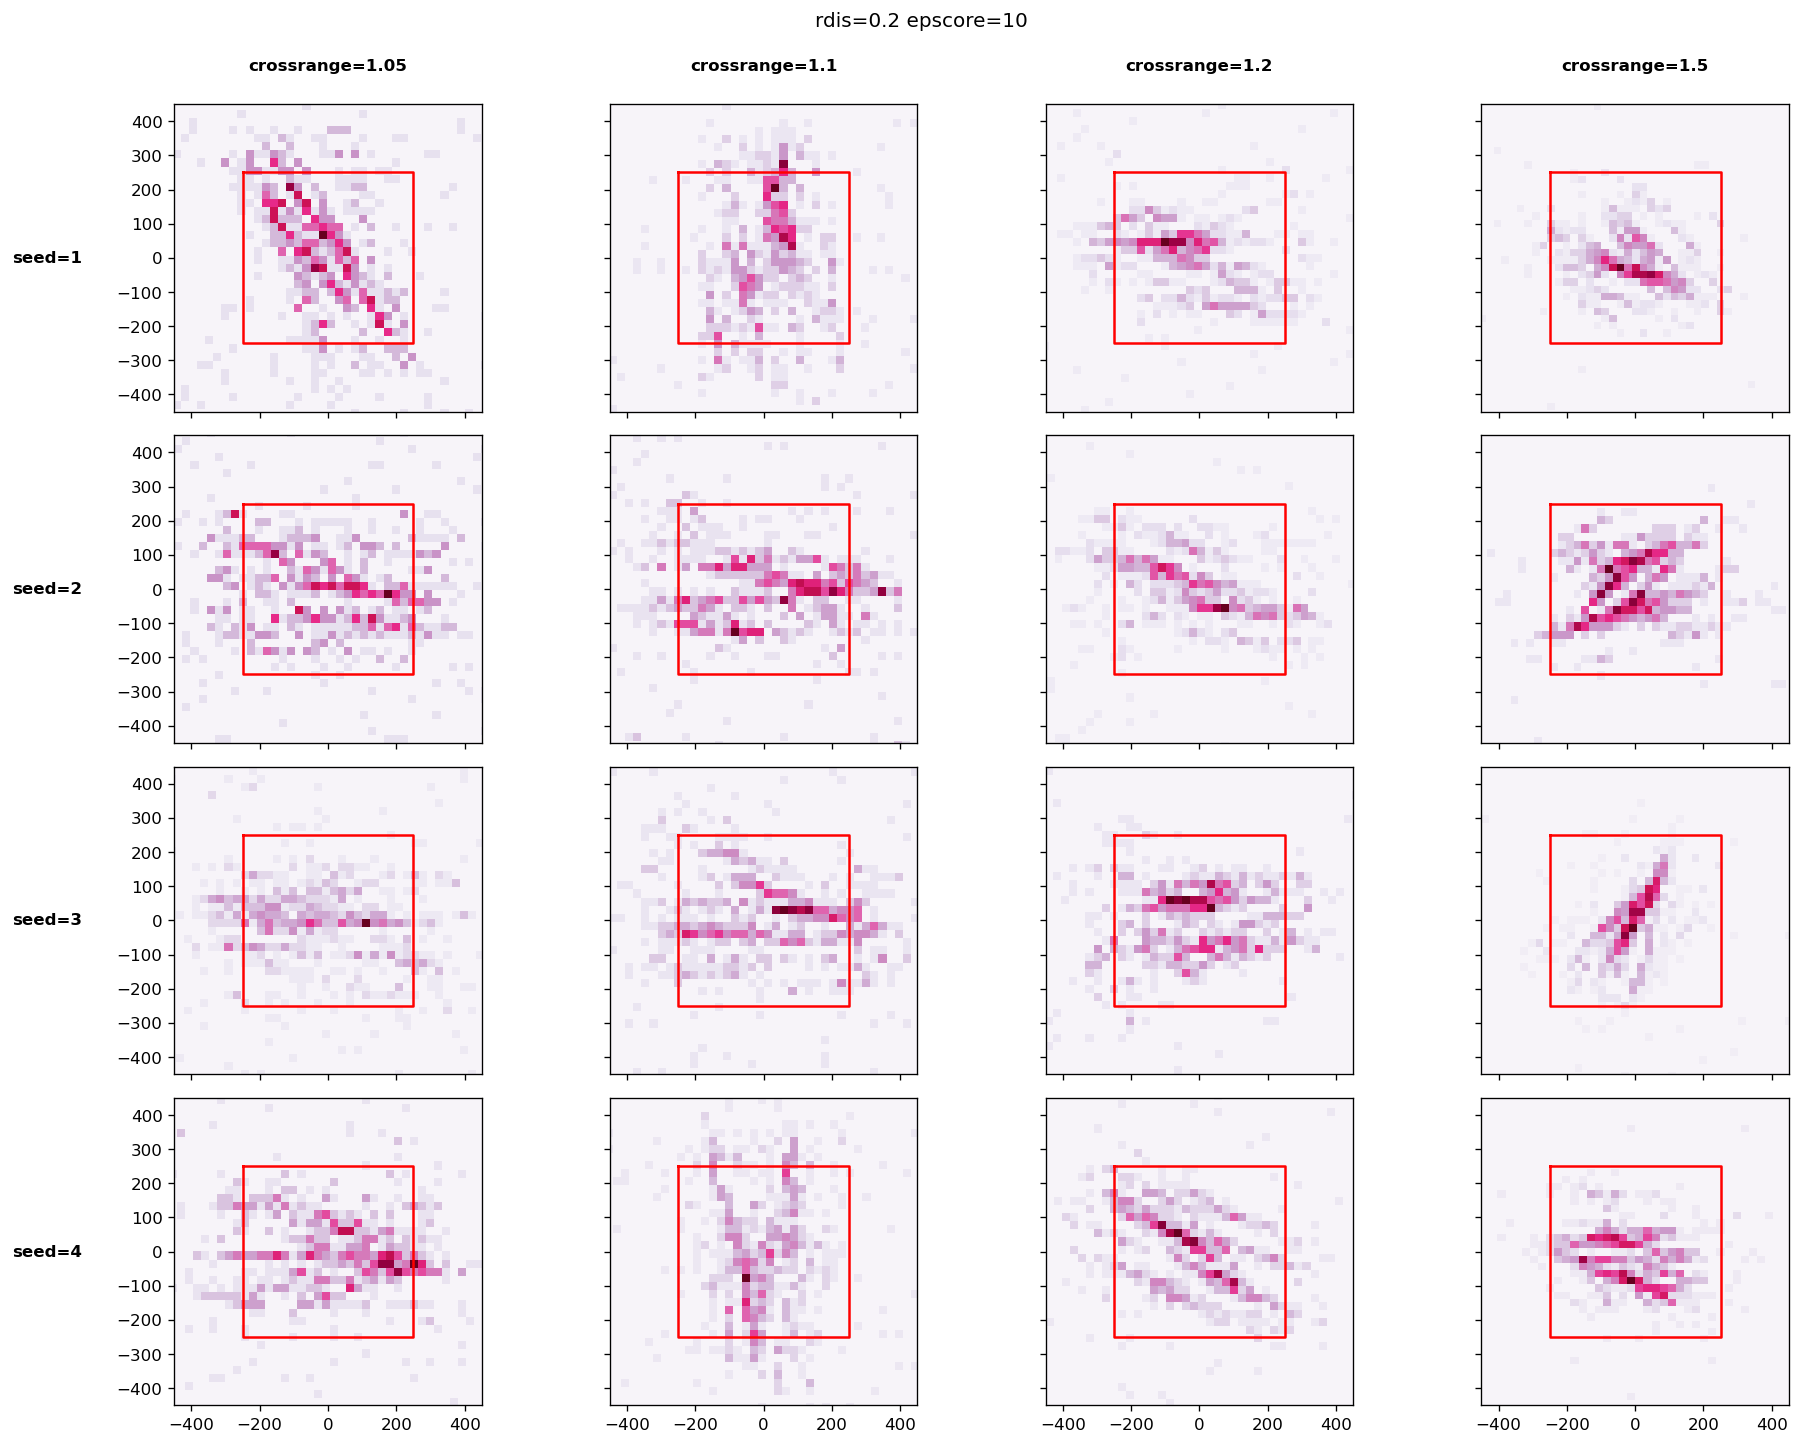

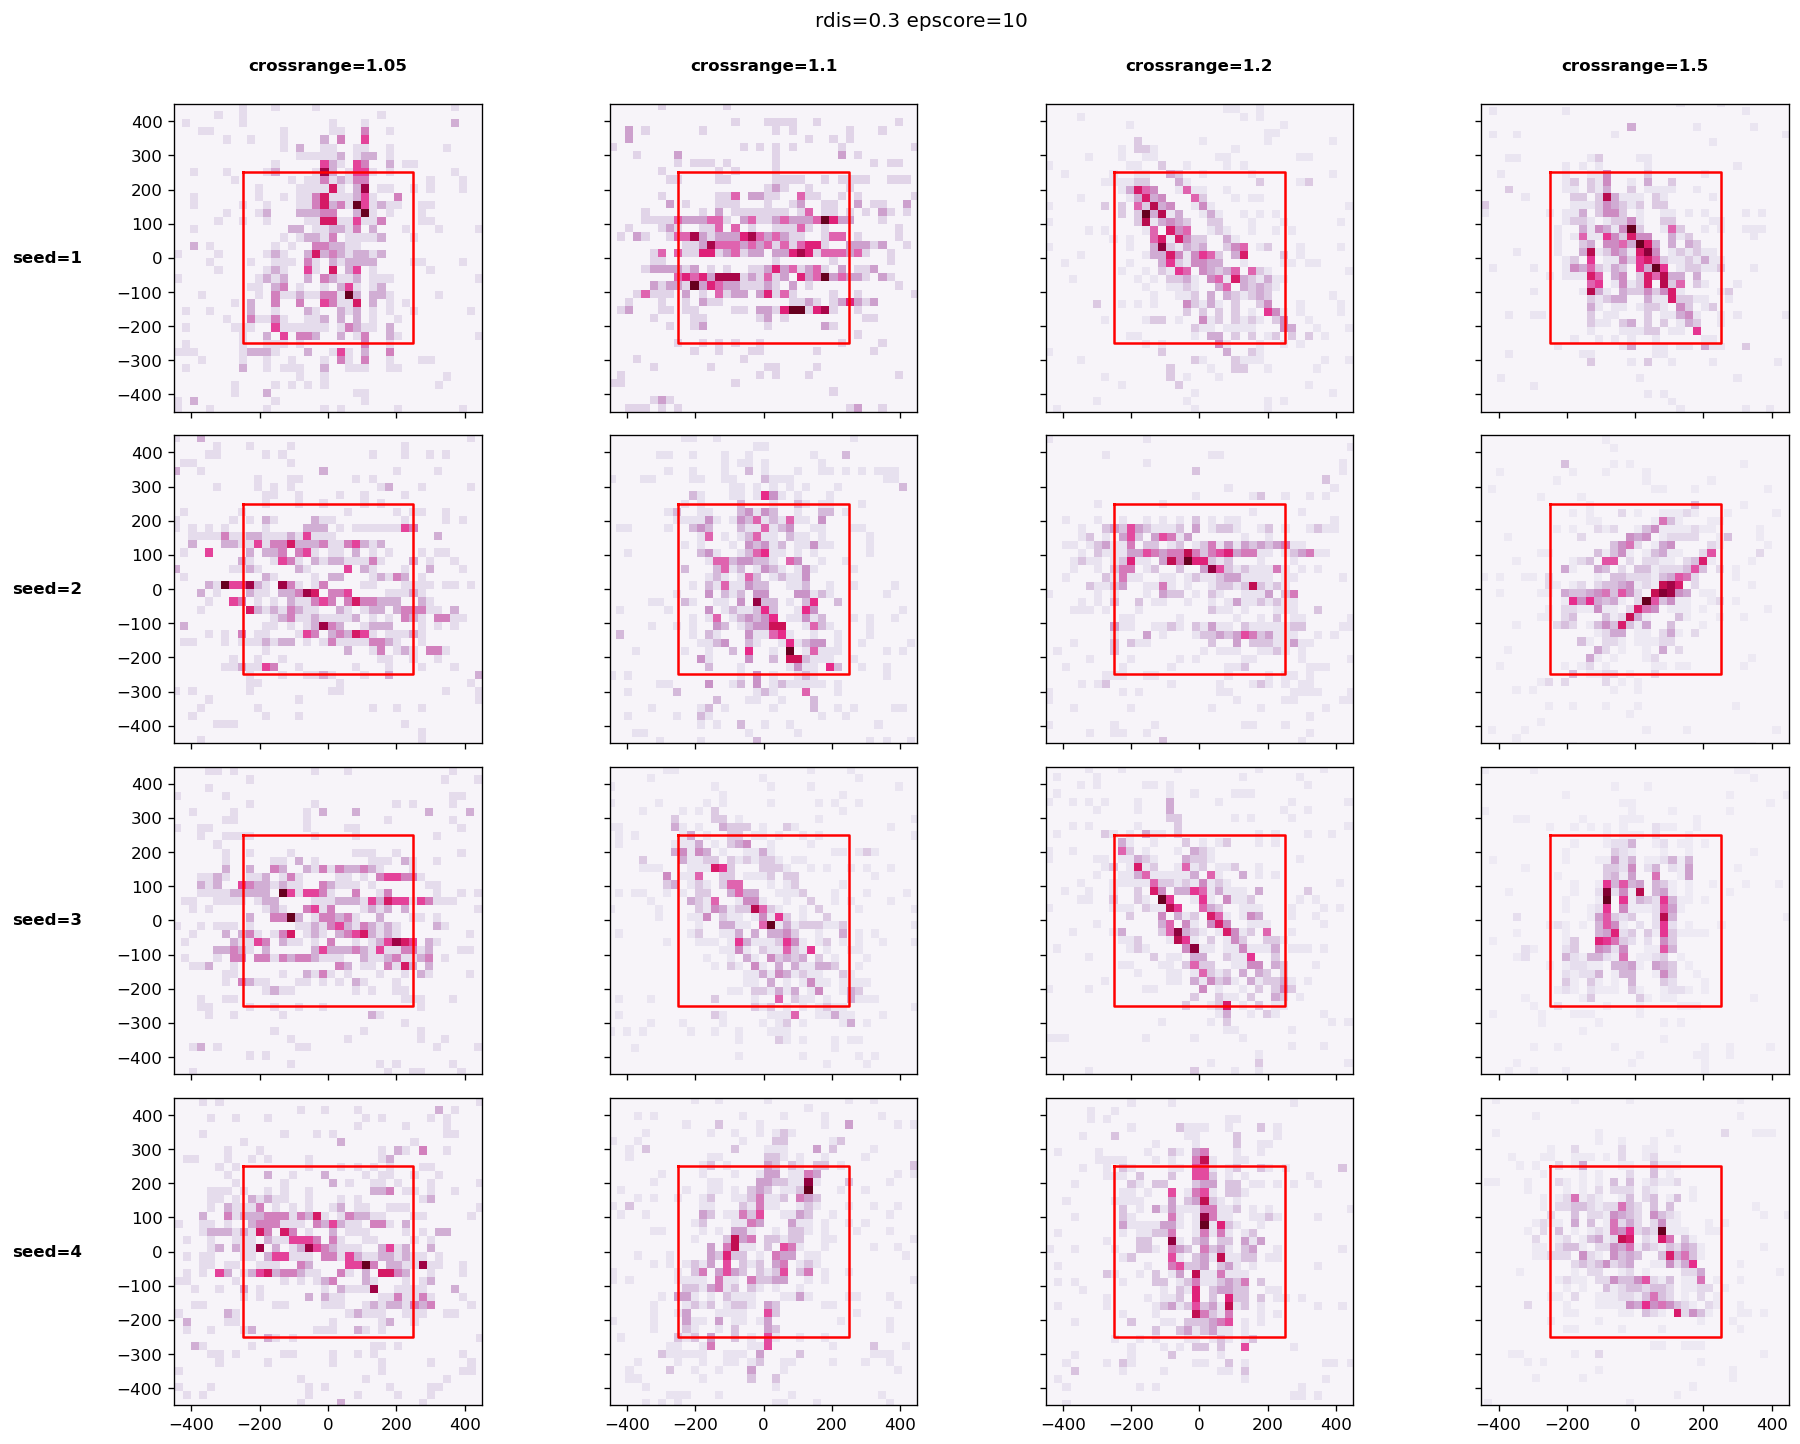

In [10]:
xylim = 450
fct.plot.plot_data_(prm, D,
        grid_params=['seed', 'crossrange'],
        overlay_params=[],
        fixed_params={"epscore": 10},
        plot_function=lambda key, ax, overlay:
            fct.box.synth_scatter(ax, key, D),
        check_key="finalframe",
        axis_edits={"set_aspect": "equal",
                    "set_xlim": (-xylim,xylim),
                    "set_ylim": (-xylim,xylim),
                    },
    )